# A simple 1D model implementation


In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from seapopym.configuration.no_transport import (
    ForcingParameter,
    ForcingUnit,
    FunctionalGroupParameter,
    FunctionalGroupUnit,
    FunctionalTypeParameter,
    MigratoryTypeParameter,
    NoTransportConfiguration,
)
from seapopym.model import NoTransportModel
from seapopym.standard.coordinate_authority import (
    create_latitude_coordinate,
    create_layer_coordinate,
    create_longitude_coordinate,
    create_time_coordinate,
)
from seapopym.standard.units import StandardUnitsLabels


## Generating data for the 1D simulation

Let's generate some data for the 1D simulation. In this NoTransport model, only temperature and primary production are required. The temperature is generated as a sine wave with a period of 1 year and the primary production is randomly generated.


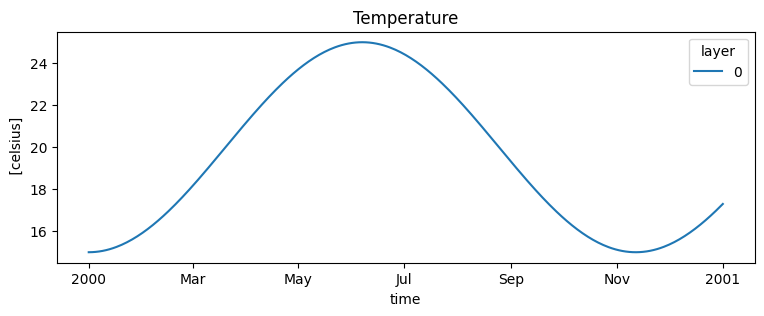

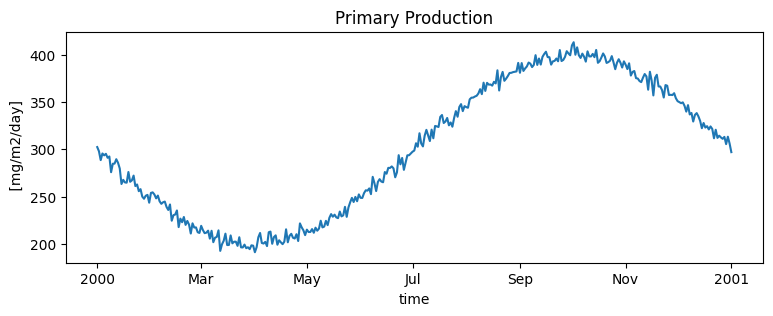

In [77]:
T_axis = create_time_coordinate(pd.date_range("2000-01-01", "2001-01-01", freq="D"))
n = int(T_axis.size)
t = np.linspace(0, 1, n)

temperature_sin = 20 + 5 * np.sin((2 * np.pi * t) + t - np.pi/2)
temperature_cte = np.ones_like(t) * 20

temperature = xr.DataArray(
    dims=["T", "Y", "X", "Z"],
    coords={
        "T": create_time_coordinate(pd.date_range("2000-01-01", "2001-01-01", freq="D")),
        "Y": create_latitude_coordinate([0]),
        "X": create_longitude_coordinate([0]),
        "Z": create_layer_coordinate([0]),
    },
    attrs={"units": StandardUnitsLabels.temperature},
    data=temperature_sin[:, np.newaxis, np.newaxis, np.newaxis],
)

plt.figure(figsize=(9, 3))
temperature[:, 0, 0].cf.plot.line(x="T")
plt.title("Temperature")
plt.show()


pp_rand = np.random.rand(367, 1, 1) * 10 + 300

rand_part = np.random.normal(loc=300, scale=5, size=(367, 1, 1))
sinus = 100 * np.sin(np.linspace(0, 2 * np.pi, 367) - np.pi)  
pp_rand_sin = rand_part + sinus.reshape(-1, 1, 1)

primary_production = xr.DataArray(
    dims=["T", "Y", "X"],
    coords={
        "T": create_time_coordinate(pd.date_range("2000-01-01", "2001-01-01", freq="D")),
        "Y": create_latitude_coordinate([0]),
        "X": create_longitude_coordinate([0]),
    },
    attrs={"units": "mg/m2/day"},
    data=pp_rand_sin,
)

plt.figure(figsize=(9, 3))
primary_production.plot()
plt.title("Primary Production")
plt.show()

dataset = xr.Dataset({"temperature": temperature, "primary_production": primary_production})

## Initialize the model

First we set up the model parameters. We will define a single functional group with the commonly used parameters for the zooplankton in Seapodym LMTL.


In [78]:
day_layer = 0
night_layer = 0
tr_0 = 10.38
gamma_tr = -0.11
lambda_temperature_0 = 1 / 150
gamma_lambda_temperature = 0.15

f_groups = FunctionalGroupParameter(
    functional_group=[
        FunctionalGroupUnit(
            name=f"D{day_layer}N{night_layer}",
            energy_transfert=0.1668,
            migratory_type=MigratoryTypeParameter(day_layer=day_layer, night_layer=night_layer),
            functional_type=FunctionalTypeParameter(
                lambda_temperature_0=lambda_temperature_0,
                gamma_lambda_temperature=gamma_lambda_temperature,
                tr_0=tr_0,
                gamma_tr=gamma_tr,
            ),
        )
    ]
)

p_param = ForcingParameter(
    temperature=ForcingUnit(forcing=dataset["temperature"]),
    primary_production=ForcingUnit(forcing=dataset["primary_production"]),
)

parameters = NoTransportConfiguration(forcing=p_param, functional_group=f_groups)

primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.
primary_production unit is milligram / day / meter ** 2, it will be converted to kilogram / day / meter ** 2.


## Run the model with context manager

The new recommended way to use Seapopym models is with a context manager. This ensures automatic memory cleanup after model execution, which is especially important for genetic algorithms or repeated simulations.


In [79]:
# Recommended: Using context manager for automatic memory cleanup
with NoTransportModel.from_configuration(configuration=parameters) as model:
    model.run()
    # Extract results while still in context
    biomass = model.state["biomass"].copy()  # Important: copy() for external use
    display(model.state)

<xarray.Dataset> Size: 31kB
Dimensions:                       (functional_group: 1, T: 367, Y: 1, X: 1,
                                   cohort: 11, Z: 1)
Coordinates:
  * functional_group              (functional_group) int64 8B 0
  * T                             (T) datetime64[ns] 3kB 2000-01-01 ... 2001-...
  * Y                             (Y) int64 8B 0
  * X                             (X) int64 8B 0
  * cohort                        (cohort) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * Z                             (Z) int64 8B 0
Data variables: (12/28)
    biomass                       (functional_group, T, Y, X) float64 3kB 0.0...
    recruited                     (functional_group, T, Y, X) float64 3kB 0.0...
    mortality_field               (functional_group, T, Y, X) float64 3kB 0.9...
    mask_temperature              (functional_group, T, Y, X, cohort) bool 4kB ...
    min_temperature               (functional_group, cohort) float64 88B 21.2...
    primary_production_by_fgroup  (functional_group, T, Y, X) float64 3kB 5.0...
    ...                            ...
    max_timestep                  (functional_group, cohort) float64 88B 1.0 ...
    mean_timestep                 (functional_group, cohort) float64 88B 1.0 ...
    timestep                      float64 8B 1.0
    angle_horizon_sun             float64 8B 0.0
    compute_initial_conditions    bool 1B False
    compute_preproduction         bool 1B False

## Plotting the results

### The biomass evolution over T


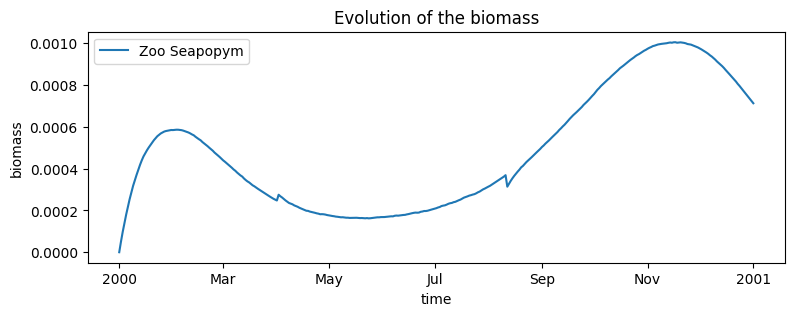

In [80]:
plt.figure(figsize=(9, 3))
biomass.mean(["Y", "X"]).plot(label="Zoo Seapopym", x="T", hue="functional_group")
plt.legend()
plt.title("Evolution of the biomass")
plt.show()